In [ ]:
#label encoding for categorical columns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('air_defense_advanced_data.csv')

le = LabelEncoder()

#applying LabelEncoder to each categorical column

df['Radar Type'] = le.fit_transform(df['Radar Type'])
df['Detection Type'] = le.fit_transform(df['Detection Type'])
df['Missile Type'] = le.fit_transform(df['Aircraft Type'])
df['Aircraft Type'] = le.fit_transform(df['Missile Type'])
df['Drone Type'] = le.fit_transform(df['Aircraft Type'])
df['Threat Level'] = le.fit_transform(df['Drone Type'])
df['Radar Signature'] = le.fit_transform(df['Threat Level'])
df['Detection Status'] = le.fit_transform(df['Radar Signature'])
df['Target Class'] = le.fit_transform(df['Target Class']) 
         
df.head()

,Radar Type,Detection Type,Missile Type,Aircraft Type,Drone Type,Threat Level,Altitude,Speed,Distance From Target,Heading,Radar Signature,Detection Status,Target Class
0,0,1,2,2,2,2,9006.36,506.57,375.83,247.08,2,2,12
1,2,2,0,0,0,0,11420.56,337.03,452.21,280.32,0,0,10
2,2,0,1,1,1,1,13039.72,379.08,412.97,94.49,1,1,4
3,1,1,1,1,1,1,14624.73,625.56,273.74,247.29,1,1,8
4,0,0,4,4,4,4,5709.53,1270.01,296.29,15.51,4,4,12


In [5]:
#splitting the dataset into training and testing sets

from sklearn.model_selection import train_test_split

#feature X and target y
X = df.drop(columns=['Target Class'])
y = df['Target Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
#training the random forest classifier

from sklearn.ensemble import RandomForestClassifier

#initialize the random forest classifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#train the model on the training data
rf_model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

Accuracy:  0.24
Classification Report:                precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.17      0.07      0.10        14
           2       0.22      0.25      0.24         8
           3       0.00      0.00      0.00        15
           4       0.50      0.47      0.48        15
           5       0.43      0.43      0.43        21
           6       0.00      0.00      0.00         6
           7       0.40      0.83      0.54        12
           8       0.30      0.15      0.20        20
           9       0.27      0.75      0.40         8
          10       0.33      0.10      0.15        21
          11       0.00      0.00      0.00        16
          12       0.14      0.24      0.18        34

    accuracy                           0.24       200
   macro avg       0.21      0.25      0.21       200
weighted avg       0.23      0.24      0.21       200



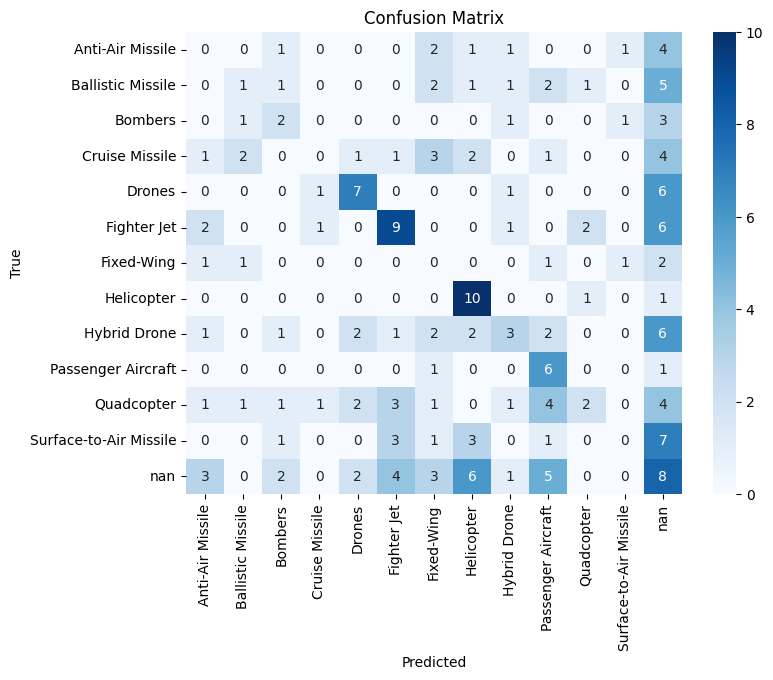

In [9]:
#Evaluating the Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#predict on the test set
y_pred = rf_model.predict(X_test)

#evaluate the model

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Classification Report: ', classification_report(y_test, y_pred))


#confusion matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


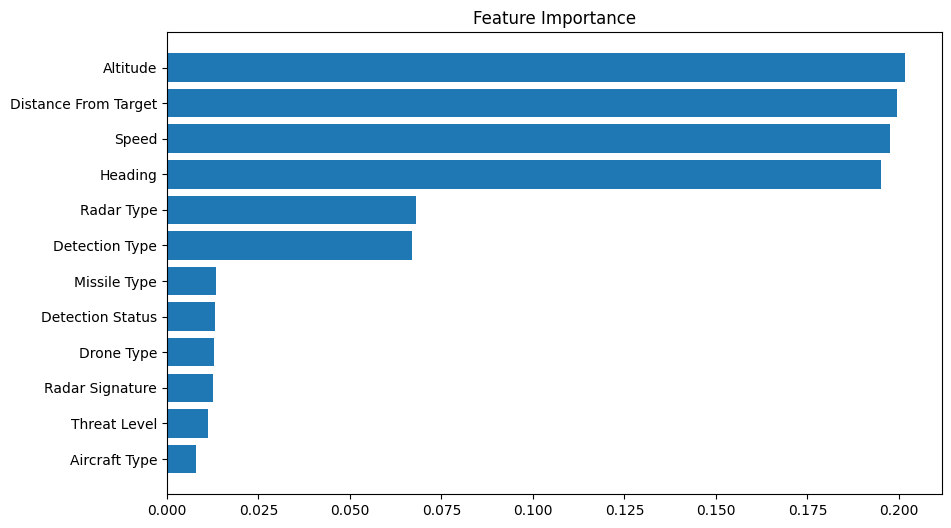

In [11]:
#visualizing feature importance

feature_importances = rf_model.feature_importances_

#sort feautures by importance
sorted_idx = feature_importances.argsort()

#plot the feature importances
plt.figure(figsize=(10,6))
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.title('Feature Importance')
plt.show()


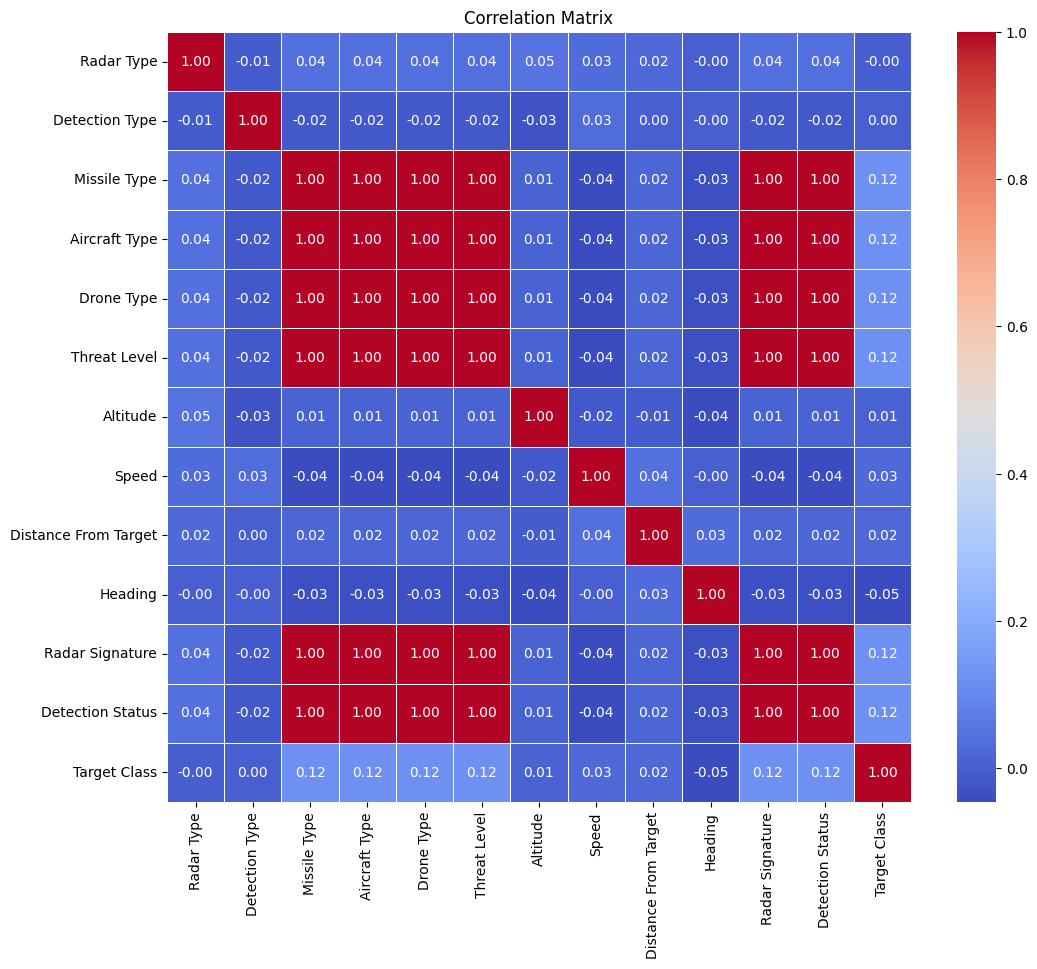

In [13]:
# Correlation matrix with respect to the Target Class
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


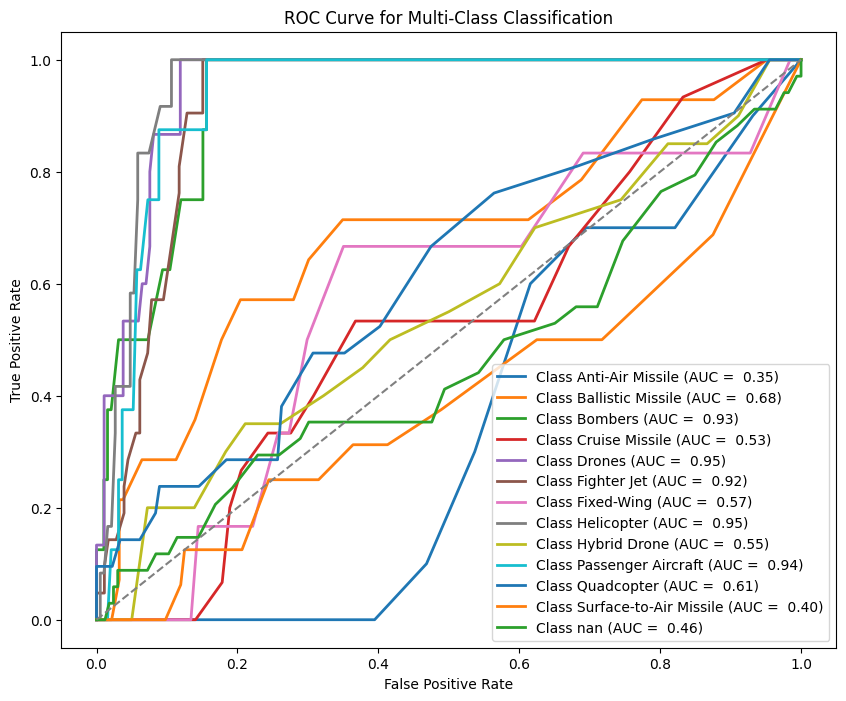

In [19]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

#binarize the output labels for multiclass ROC
y_bin = label_binarize(y_test, classes=np.unique(y))

#fit the model and get predictions for each class
y_score = rf_model.predict_proba(X_test)

#plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {le.classes_[i]} (AUC = {roc_auc: .2f})')
    
#format the plot
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()


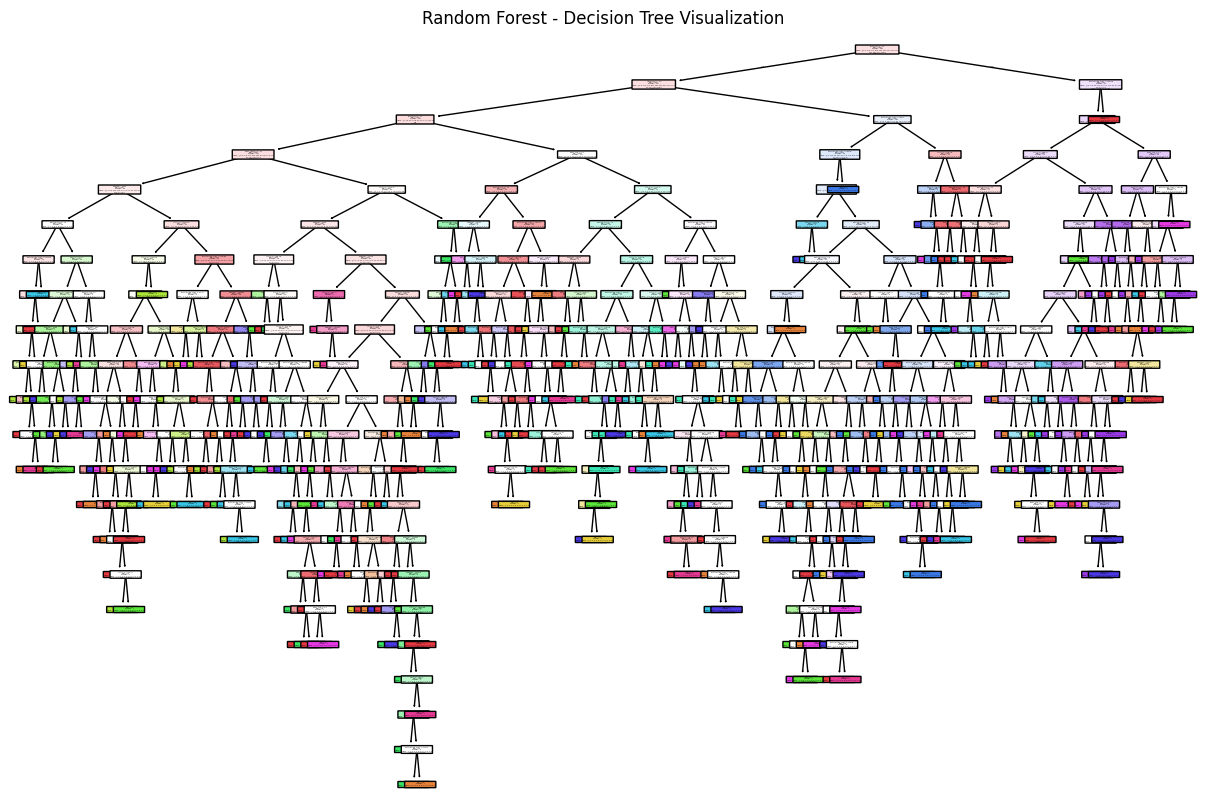

In [21]:
from sklearn.tree import plot_tree

# Convert class labels to strings if they are not already
class_names = [str(i) for i in le.classes_]

# Visualize one of the decision trees in the random forest
plt.figure(figsize=(15, 10))
plot_tree(rf_model.estimators_[0], 
          feature_names=X.columns, 
          class_names=class_names, 
          filled=True, 
          rounded=True)
plt.title('Random Forest - Decision Tree Visualization')
plt.show()
